Accuracy: 1.0


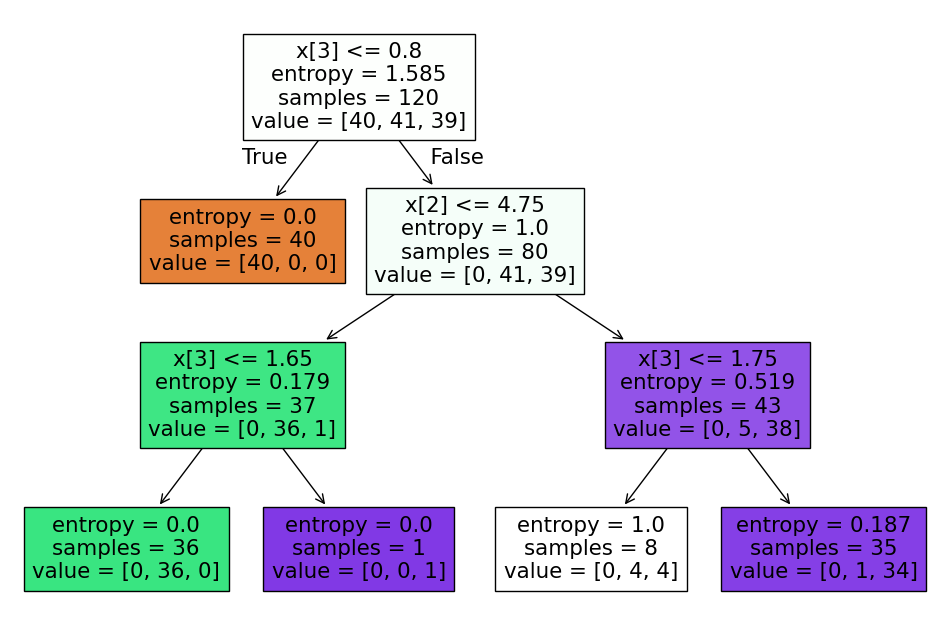

training accuracy:  0.9583333333333334
testing accuracy:  1.0


In [13]:
# import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split    

data  = load_iris()

X = data.data
y =data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state  =42)

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy', max_depth=3)

# note one points (if train keeps increasing and test not improving then it is overfitting)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print("training accuracy: ", train_acc)
print("testing accuracy: ", test_acc)


# in this situation the training accuracy is 1.0 which means the model has perfectly fit the training data, while the testing accuracy is 1.0 which indicates that the model also performs perfectly on the unseen test data, suggesting that it has good generalization capabilities and is not overfitting the training data.


# NOTE:
# why testing accuracy is higher than training accuracy??
# This can happen when the test set is small or slightly easier than the training set. Since we are using a simple dataset like Iris, it is possible for the model to achieve 100% accuracy on test data without overfitting.”


# -----------------------------------------check for overfitting --------------------------------------------
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(model, X, y, cv=5)

# print("Scores:", scores)
# print("Average:", scores.mean())

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



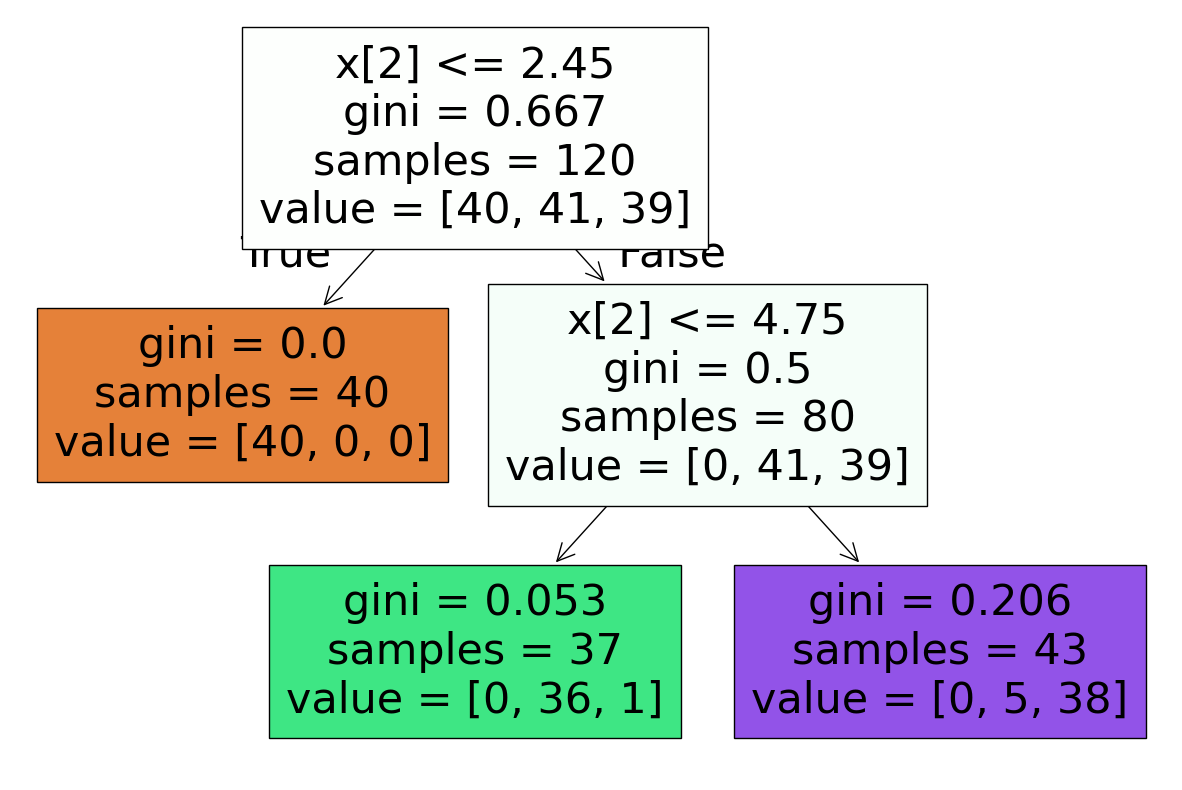

In [13]:
# post pruning model 

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.datasets import load_iris


data = load_iris()



import seaborn as sns

df = sns.load_dataset('iris')

# df.head()



#independent features   
X = df.iloc[:, :-1]
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()

from sklearn.tree import DecisionTreeClassifier
#post pruning
treemodel = DecisionTreeClassifier(max_depth=2)

treemodel.fit(X_train, y_train)


from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treemodel, filled=True)

##prediction
y_pred = treemodel.predict(X_test)
# y_pred

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(  y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

In [19]:
##pre-pruning model 

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.datasets import load_iris


data = load_iris()
import seaborn as sns

df = sns.load_dataset('iris')

# df.head()
#independent features   
X = df.iloc[:, :-1]
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train.head()



parametrs ={
    'max_depth': [2,3,4,5],
    'splitter': ['best', 'random'],
    'criterion': ['gini', 'entropy'],
    'max_features': ['auto', 'sqrt', 'log2']
}
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
#post pruning
treemodel = DecisionTreeClassifier(max_depth=2)

cv = GridSearchCV(treemodel, param_grid=parametrs, cv=5, scoring='accuracy')
cv.fit(X_train, y_train)

cv.best_params_   #to get the best parameters and best score from that parameters we can use the parameters in the model and fit it again to get the best accuracy

y_pred = cv.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 471